# 03 · Tuning, final evaluation and results

1. Tune gradient boosting with **time-series cross-validation** on train + validation.
2. Check the finalists for overfitting.
3. Evaluate the chosen model **once** on the test quarter (Oct–Dec 2025), which no earlier step has seen.
4. Break the error down by store type, store age and category, and translate it into recommendations.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import data_prep as dp, plot_style as ps

ps.apply()
pd.options.display.float_format = "{:,.2f}".format
IMG = Path.cwd().parent / "images"
DATA_PATH, DATA_MODE = dp.resolve_data_path()
print(f"Using {DATA_MODE} dataset: {DATA_PATH.name}")

import json, joblib
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

MODELS = Path.cwd().parent / "models"
config = json.loads((MODELS / "feature_config.json").read_text())
NUMERIC, RANDOM_STATE = config["numeric"], config["random_state"]
FEATURES = dp.CATEGORICAL + NUMERIC + dp.BOOLEAN
print("Features:", FEATURES)

Using full dataset: valle_central_ventas_semanales.csv


Features: ['categoria', 'tipo_sucursal', 'precio', 'lag_1', 'lag_2', 'lag_4', 'std_movil_4', 'semana_transcurrida', 'media_movil_8', 'promocion', 'promocion_sin_registro', 'es_feriado_temporada', 'es_quincena', 'es_diciembre', 'perecedero']


In [2]:
train, val, test = dp.prepare(DATA_PATH)
train_val = pd.concat([train, val]).sort_values("fecha")   # chronological order for TimeSeriesSplit

prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), dp.CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
], remainder="passthrough")
pipeline = Pipeline([("prep", prep), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])

# Grid search = 36+ fits. To keep it tractable on one CPU, tuning uses a systematic
# 1-in-4 sample that preserves chronological order. The SAME sample is used for every
# search below so results are comparable. The final model is refit on 100% of the data.
search_sample = train_val.iloc[::4]
X_s, y_s = search_sample[FEATURES], search_sample.unidades
cv = TimeSeriesSplit(n_splits=3)
print(f"Tuning sample: {len(search_sample):,} of {len(train_val):,} rows")

Tuning sample: 118,745 of 474,980 rows


## 1. Core hyperparameters

In [3]:
grid = {"model__n_estimators": [100, 200],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.05, 0.1]}
search = GridSearchCV(pipeline, grid, cv=cv, scoring="neg_mean_absolute_error").fit(X_s, y_s)

experiments = (pd.DataFrame(search.cv_results_)
               .assign(cv_MAE=lambda d: -d.mean_test_score, cv_std=lambda d: d.std_test_score)
               [["param_model__n_estimators", "param_model__max_depth", "param_model__learning_rate", "cv_MAE", "cv_std"]]
               .rename(columns=lambda c: c.replace("param_model__", ""))
               .sort_values("cv_MAE").reset_index(drop=True))
experiments

,n_estimators,max_depth,learning_rate,cv_MAE,cv_std
0,100,3,0.05,22.05,2.20
1,100,4,0.05,22.18,2.28
2,100,3,0.10,22.25,2.57
3,200,3,0.05,22.27,2.57
4,100,4,0.10,22.45,2.86
5,200,4,0.05,22.46,2.86
6,100,2,0.05,22.49,2.14
7,200,3,0.10,22.56,3.10
8,200,2,0.10,22.64,2.45
9,200,4,0.10,22.73,3.21


All 12 configurations land within ~1 unit of each other, and the fold-to-fold standard deviation (~2 units) is larger than the gaps between them. **Tuning is not where the remaining error lives**: it's in what the features can't see (sold-out weeks, promotions not yet recorded, unusual December weeks).

## 2. Regularization hyperparameters (same sample, same folds)

In [4]:
best_core = search.best_params_
grid_reg = {**{k: [v] for k, v in best_core.items()},
            "model__min_samples_leaf": [1, 20, 50],
            "model__subsample": [0.8, 1.0]}
search_reg = GridSearchCV(pipeline, grid_reg, cv=cv, scoring="neg_mean_absolute_error").fit(X_s, y_s)

reg_table = (pd.DataFrame(search_reg.cv_results_)
             .assign(cv_MAE=lambda d: -d.mean_test_score)
             [["param_model__min_samples_leaf", "param_model__subsample", "cv_MAE"]]
             .rename(columns=lambda c: c.replace("param_model__", ""))
             .sort_values("cv_MAE").reset_index(drop=True))
display(reg_table)
gain = -search.best_score_ - (-search_reg.best_score_)
print(f"Best core-only CV MAE: {-search.best_score_:.3f} · with regularization: {-search_reg.best_score_:.3f} · gain: {gain:.3f} units")

,min_samples_leaf,subsample,cv_MAE
0,20,1.00,22.03
1,50,1.00,22.05
2,1,1.00,22.05
3,1,0.80,22.10
4,50,0.80,22.14
5,20,0.80,22.15


Best core-only CV MAE: 22.053 · with regularization: 22.028 · gain: 0.025 units


In [5]:
# Keep the extra hyperparameters only if they buy a meaningful improvement (> 0.1 units)
best_params = search_reg.best_params_ if gain > 0.1 else best_core
print("Candidate configuration:", best_params)

Candidate configuration: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


`min_samples_leaf` and `subsample` change the CV error by a few hundredths of a unit, well below the 0.1-unit threshold. They are left at their defaults to keep the model simpler.

## 3. Overfitting check on the finalists

The top configurations are usually within a fraction of a unit of each other. As a tie-breaker, each finalist is trained on the training period only and compared on train vs. validation MAE. A validation error much *higher* than training error signals overfitting.

In [6]:
finalists = [dict(p) for p in experiments.head(3)[["n_estimators", "max_depth", "learning_rate"]].to_dict("records")]
if best_params not in [{f"model__{k}": v for k, v in f.items()} for f in finalists]:
    finalists.append({k.replace("model__", ""): v for k, v in best_params.items()})

rows = []
for f in finalists:
    params = {f"model__{k}": v for k, v in f.items()}
    m = clone(pipeline).set_params(**params).fit(train[FEATURES], train.unidades)
    mae_tr = mean_absolute_error(train.unidades, m.predict(train[FEATURES]))
    mae_va = mean_absolute_error(val.unidades, m.predict(val[FEATURES]))
    rows.append({**f, "train MAE": mae_tr, "val MAE": mae_va, "val − train": mae_va - mae_tr})
finalist_table = pd.DataFrame(rows)
finalist_table

,n_estimators,max_depth,learning_rate,train MAE,val MAE,val − train
0,100,3,0.05,19.65,18.03,-1.61
1,100,4,0.05,19.12,17.83,-1.29
2,100,3,0.10,19.03,17.80,-1.23


Validation MAE comes out *lower* than training MAE for every finalist. That isn't a bug: the validation quarter (Jul–Sep) has no December peaks, while the training period includes two Decembers, the hardest weeks to forecast. What matters is that no finalist shows the opposite pattern (validation clearly worse than training), so none is overfitting; the choice goes to the best validation MAE.

In [7]:
winner = finalist_table.sort_values("val MAE").iloc[0]
final_params = {f"model__{k}": winner[k] for k in finalists[0].keys()}
final_params = {k: (int(v) if float(v).is_integer() and k != "model__learning_rate" and k != "model__subsample" else float(v))
                for k, v in final_params.items()}
print("Final configuration:", final_params)

final_model = clone(pipeline).set_params(**final_params)
final_model.fit(train_val[FEATURES], train_val.unidades)    # 100% of train + validation
print("Refit on", f"{len(train_val):,}", "rows.")

Final configuration: {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}


Refit on 474,980 rows.


## 4. Final evaluation — test quarter, run once

Everything above was decided without looking at these 13 weeks.

In [8]:
assert not set(dp.LEAKAGE_COLUMNS) & set(FEATURES), "leakage column in features"
assert train.fecha.max() < val.fecha.min() and val.fecha.max() < test.fecha.min(), "partitions overlap in time"

test = test.assign(forecast=final_model.predict(test[FEATURES]))
y, yhat, base = test.unidades, test.forecast, test.media_movil_4

results = pd.DataFrame({
    "Model":    [mean_absolute_error(y, yhat), mean_squared_error(y, yhat) ** 0.5, dp.wape(y, yhat) * 100, dp.mape_nonzero(y, yhat) * 100],
    "Baseline": [mean_absolute_error(y, base), mean_squared_error(y, base) ** 0.5, dp.wape(y, base) * 100, dp.mape_nonzero(y, base) * 100],
}, index=["MAE (units)", "RMSE (units)", "WAPE %", "MAPE % (non-zero weeks)"])
results["Improvement %"] = (results.Baseline - results.Model) / results.Baseline * 100
display(results)

improvement = results.loc["MAE (units)", "Improvement %"]
print(f"MAE improvement vs planner's rule: {improvement:.1f}% → target ≥20%: {'MET' if improvement >= 20 else 'NOT MET'}")

,Model,Baseline,Improvement %
MAE (units),21.25,28.71,25.98
RMSE (units),35.93,50.14,28.34
WAPE %,27.08,36.58,25.98
MAPE % (non-zero weeks),31.68,38.61,17.96


MAE improvement vs planner's rule: 26.0% → target ≥20%: MET


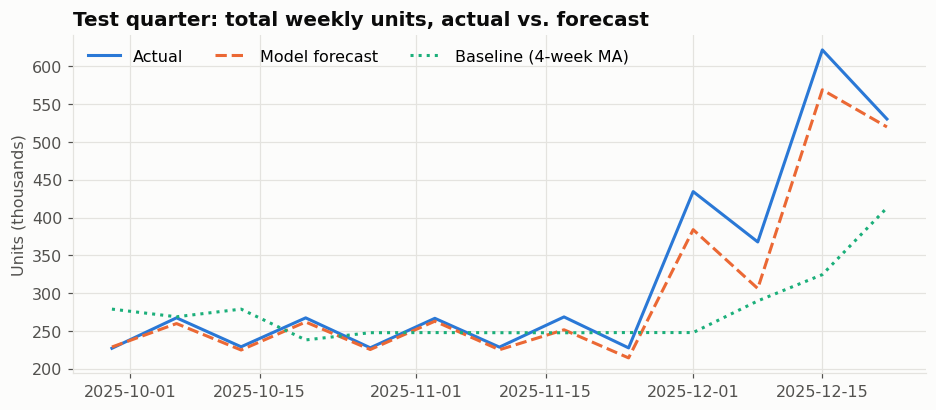

In [9]:
weekly = test.groupby("fecha")[["unidades", "forecast", "media_movil_4"]].sum() / 1000

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly.index, weekly.unidades, color=ps.BLUE, label="Actual")
ax.plot(weekly.index, weekly.forecast, color=ps.ORANGE, ls="--", label="Model forecast")
ax.plot(weekly.index, weekly.media_movil_4, color=ps.AQUA, ls=":", label="Baseline (4-week MA)")
ax.set_title("Test quarter: total weekly units, actual vs. forecast")
ax.set_ylabel("Units (thousands)")
ax.legend(loc="upper left", ncol=3)
fig.savefig(IMG / "test_forecast.png")
plt.show()

## 5. Where the error lands

In [10]:
def segment_table(col):
    return (test.groupby(col)
                .apply(lambda g: pd.Series({
                    "rows": len(g),
                    "model WAPE %": dp.wape(g.unidades, g.forecast) * 100,
                    "baseline WAPE %": dp.wape(g.unidades, g.media_movil_4) * 100,
                    "model MAE": mean_absolute_error(g.unidades, g.forecast)}), include_groups=False))

fair = segment_table("tipo_sucursal")
display(fair)
print(f"Urban vs rural WAPE gap: {fair['model WAPE %'].max() - fair['model WAPE %'].min():.1f} pp (threshold 10 pp)")

,rows,model WAPE %,baseline WAPE %,model MAE
tipo_sucursal,,,,
rural,"17,680.00",28.15,37.34,15.95
urbana,"35,360.00",26.74,36.34,23.91


Urban vs rural WAPE gap: 1.4 pp (threshold 10 pp)


In [11]:
test["store_age"] = np.where(test.id_sucursal.isin(["S11", "S12"]), "new (opened 2025)", "established")
segment_table("store_age")

,rows,model WAPE %,baseline WAPE %,model MAE
store_age,,,,
established,"44,200.00",26.89,36.47,22.29
new (opened 2025),"8,840.00",28.42,37.35,16.06


,rows,model WAPE %,baseline WAPE %,model MAE
categoria,,,,
Bebidas,"6,708.00",26.45,36.43,19.39
Embutidos,"3,120.00",26.59,36.67,21.72
Panadería,"2,808.00",26.83,36.39,24.05
Higiene personal,"7,488.00",26.86,36.57,23.08
Lácteos,"4,212.00",27.02,36.80,21.28
Abarrotes,"7,020.00",27.04,36.28,23.34
Snacks,"6,864.00",27.28,36.56,21.62
Frutas y verduras,"4,368.00",27.46,36.84,23.34
Carnes,"4,680.00",27.63,36.67,19.39


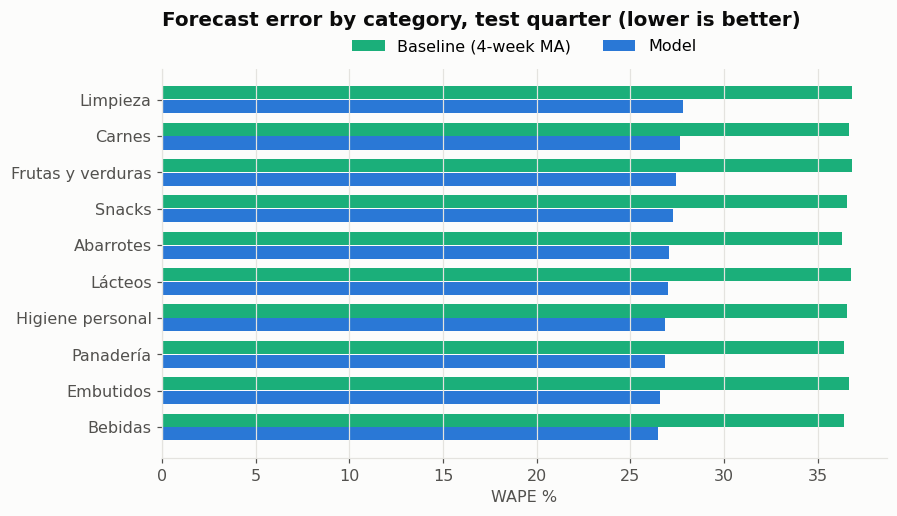

In [12]:
by_cat = segment_table("categoria").sort_values("model WAPE %")
display(by_cat)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ypos = np.arange(len(by_cat))
ax.barh(ypos + 0.19, by_cat["baseline WAPE %"], height=0.36, color=ps.AQUA, label="Baseline (4-week MA)")
ax.barh(ypos - 0.19, by_cat["model WAPE %"], height=0.36, color=ps.BLUE, label="Model")
ax.set_yticks(ypos, by_cat.index)
ax.set_title("Forecast error by category, test quarter (lower is better)")
ax.set_xlabel("WAPE %")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
ax.set_title("Forecast error by category, test quarter (lower is better)", pad=28)
fig.savefig(IMG / "category_wape.png")
plt.show()

Relative error (WAPE) is almost flat across categories, between roughly 26 % and 28 %. Categories like Panadería or Abarrotes show a higher error *in units* only because they sell more units. In relative terms the model is equally reliable across the catalogue, and it beats the baseline by about 9–10 points in every category.

### December: the weeks that matter most

In [13]:
test["period"] = np.where(test.es_diciembre, "December", "Oct–Nov")
dec = test.groupby("period").apply(lambda g: pd.Series({
    "model MAE": mean_absolute_error(g.unidades, g.forecast),
    "baseline MAE": mean_absolute_error(g.unidades, g.media_movil_4),
    "model bias %": (g.forecast.sum() / g.unidades.sum() - 1) * 100,
    "baseline bias %": (g.media_movil_4.sum() / g.unidades.sum() - 1) * 100}), include_groups=False)
dec

,model MAE,baseline MAE,model bias %,baseline bias %
period,,,,
December,32.53,48.60,-8.97,-34.77
Oct–Nov,16.24,19.87,-2.51,4.23


The planner's 4-week average lags badly in December: it looks back at November and under-forecasts the peak by roughly a third. The model follows the peak much better (see the chart above), but still **under-forecasts December by about 9 %**. For perishables that's the safe side of the error (less waste); for non-perishables it risks stock-outs in the highest-revenue weeks.

## 6. Conclusions and recommendations

**Result.** On the held-out quarter (Oct–Dec 2025) the model cuts MAE from 28.7 to 21.3 units per product-store-week, a **26 % improvement** over the planner's current rule. That clears the ≥20 % acceptance criterion set in stage 1, and the model beats the baseline on every metric, in every category and in both store types.

**Fairness.** Urban/rural WAPE gap: 1.4 pp (threshold 10 pp). The two new rural stores are only ~1.5 pp worse than established ones despite having under a year of history.

**Recommendations for the planner**
1. Use the forecast as the **starting point** for Monday's order, not as an automatic order. The planner keeps the final decision (a stage-1 ethics requirement).
2. In December, add a manual safety margin on non-perishables, since the model runs about 9 % short.
3. Start recording promotions consistently and log stock-outs. Both are the main blind spots in the current data, and tuning more hyperparameters won't close that gap.
4. Retrain monthly and track MAE against the baseline. If the improvement drops below 20 %, investigate before continuing to use the model.

**Limitations.** Sold-out weeks record sales, not true demand (≈0.8 % of rows). The dataset is a course case study, not a live company feed.

In [14]:
joblib.dump(final_model, MODELS / "demand_forecast_gb.joblib")
print("Model saved to models/demand_forecast_gb.joblib")

Model saved to models/demand_forecast_gb.joblib
